## Hướng Dẫn Học Machine Learning Cơ Bản với Scikit-Learn
> **Mục tiêu**: Nắm vững workflow chuẩn của Machine Learning, sử dụng thư viện **Scikit-Learn (`sklearn`)**, huấn luyện & đánh giá các mô hình Phân loại (**Logistic Regression, KNN, Decision Tree**) trên tập dữ liệu Diabetes, và tối ưu hóa siêu tham số.

---


## 1. Giới thiệu về Scikit-Learn & Machine Learning Workflow
Scikit-Learn (`sklearn`) là thư viện Machine Learning hàng đầu trong Python, cung cấp các công cụ nhất quán để:
- **Tiền xử lý dữ liệu**: Xử lý missing data, chuẩn hóa đặc trưng (Feature Scaling).
- **Chia tập dữ liệu**: Phân chia Train/Test bằng `train_test_split`.
- **Huấn luyện mô hình (Estimator API)**: Dùng `fit()` để train mô hình.
- **Dự đoán**: Dùng `predict()` hoặc `predict_proba()`.
- **Đánh giá mô hình**: Các chỉ số Accuracy, Precision, Recall, F1-Score, Confusion Matrix.
- **Tối ưu siêu tham số**: Chỉnh tham số với `GridSearchCV` / `RandomizedSearchCV`.

**Quy trình 5 bước chuẩn (ML Workflow)**:
1. `Data Preparation` ➡️ 2. `Train/Test Split & Scaling` ➡️ 3. `Model Training (fit)` ➡️ 4. `Evaluation (predict)` ➡️ 5. `Hyperparameter Tuning`

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import từ scikit-learn
from sklearn.datasets import load_diabetes, load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

print(' Đã import thành công tất cả thư viện cần thiết!')

 Đã import thành công tất cả thư viện cần thiết!


## 2. Chuẩn bị Dữ liệu (Diabetes Dataset cho Bài toán Phân loại)
Chúng ta sẽ sử dụng bộ dữ liệu **Diabetes** tích hợp sẵn trong Scikit-Learn.
> *Lưu ý*: Mặc định, `load_diabetes()` có nhãn `target` là biến liên tục (dành cho Hồi quy - Regression). Để thực hành bài toán **Phân loại (Classification)** theo đúng lộ trình Taskade, chúng ta sẽ phân loại bệnh nhân thành 2 nhóm:
> - `1`: Nguy cơ tiến triển tiểu đường cao (nhãn lớn hơn trung vị).
> - `0`: Nguy cơ tiến triển tiểu đường thấp (nhãn nhỏ hơn hoặc bằng trung vị).

In [67]:
# 1. Load bộ dữ liệu Diabetes
diabetes_data = load_diabetes(as_frame=True)
X = diabetes_data.data
y_continuous = diabetes_data.target

# 2. Chuyển target thành nhị phân (0 và 1) cho bài toán Phân loại
median_val = y_continuous.median()
y = (y_continuous > median_val).astype(int)

print(f'Kích thước tập đặc trưng X: {X.shape}')
print(f'Phân bố nhãn target (0 và 1):\n{y.value_counts()}')
X.head()

Kích thước tập đặc trưng X: (442, 10)
Phân bố nhãn target (0 và 1):
target
1    221
0    221
Name: count, dtype: int64


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [68]:
# 3. Chia tập Train và Test (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Chuẩn hóa đặc trưng (Feature Scaling bằng StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Số lượng mẫu tập Train: {X_train_scaled.shape[0]}')
print(f'Số lượng mẫu tập Test: {X_test_scaled.shape[0]}')

Số lượng mẫu tập Train: 353
Số lượng mẫu tập Test: 89


## 3. Mô hình 1: Logistic Regression (Hồi quy Logistic)
- **Khái niệm**: Dù chứa từ "Regression", Logistic Regression là thuật toán **Phân loại** tuyến tính kinh điển. Mô hình tính tổng có trọng số của các đặc trưng rồi đưa qua hàm **Sigmoid** $S(z) = \frac{1}{1 + e^{-z}}$ để đưa ra xác suất $P(y=1|X) \in [0, 1]$.
- **API trong Sklearn**: `LogisticRegression()`

In [69]:
# 1. Khởi tạo mô hình
log_reg = LogisticRegression(random_state=42)

# 2. Fit (Huấn luyện) trên tập Train
log_reg.fit(X_train_scaled, y_train)

# 3. Predict (Dự đoán) trên tập Test
y_pred_log_reg = log_reg.predict(X_test_scaled)

# 4. Đánh giá nhanh Accuracy
acc_log_reg = accuracy_score(y_test, y_pred_log_reg)
print(f' Accuracy của Logistic Regression: {acc_log_reg:.4f}')

 Accuracy của Logistic Regression: 0.7416


## 4. Mô hình 2: K-Nearest Neighbors (KNN - Láng giềng gần nhất)
- **Khái niệm**: KNN phân loại mẫu dữ liệu mới dựa trên nhóm $k$ láng giềng gần nó nhất trong không gian (đo bằng khoảng cách Euclidean). Nhãn có số lượt bình chọn (majority vote) nhiều nhất sẽ được gán cho mẫu mới.
- **API trong Sklearn**: `KNeighborsClassifier(n_neighbors=5)`

In [70]:
# 1. Khởi tạo mô hình KNN với k=5
knn = KNeighborsClassifier(n_neighbors=5)

# 2. Huấn luyện mô hình
knn.fit(X_train_scaled, y_train)

# 3. Dự đoán
y_pred_knn = knn.predict(X_test_scaled)

# 4. Đánh giá Accuracy
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f' Accuracy của KNN (k=5): {acc_knn:.4f}')

 Accuracy của KNN (k=5): 0.7528


## 5. Mô hình 3: Decision Tree Classifier (Cây Quyết Định)
- **Khái niệm**: Decision Tree xây dựng cấu trúc dạng cây, liên tục phân nhánh dữ liệu dựa trên các câu hỏi điều kiện tại từng nút (node). Việc chọn điểm chia được tối ưu hóa dựa trên các chỉ số như **Gini Impurity** hoặc **Entropy**.
- **API trong Sklearn**: `DecisionTreeClassifier(max_depth=3, random_state=42)`

In [71]:
# 1. Khởi tạo mô hình Decision Tree với max_depth=3 (tránh overfitting)
dtree = DecisionTreeClassifier(max_depth=3, random_state=42)

# 2. Huấn luyện mô hình
dtree.fit(X_train_scaled, y_train)

# 3. Dự đoán
y_pred_dtree = dtree.predict(X_test_scaled)

# 4. Đánh giá Accuracy
acc_dtree = accuracy_score(y_test, y_pred_dtree)
print(f' Accuracy của Decision Tree (max_depth=3): {acc_dtree:.4f}')

 Accuracy của Decision Tree (max_depth=3): 0.6966


## 6. Đánh giá Chi tiết Mô hình Phân loại (Classification Metrics)
Khi đánh giá mô hình phân loại, **Accuracy** không phải lúc nào cũng đủ. Chúng ta cần hiểu thêm các chỉ số:
1. **Confusion Matrix (Ma trận nhầm lẫn)**:
   - `TP` (True Positive): Thực tế Dương, Dự đoán Dương.
   - `TN` (True Negative): Thực tế Âm, Dự đoán Âm.
   - `FP` (False Positive - Sai lầm loại 1): Thực tế Âm, Dự đoán Dương.
   - `FN` (False Negative - Sai lầm loại 2): Thực tế Dương, Dự đoán Âm.
2. **Precision**: $\frac{TP}{TP + FP}$ (Trong số các mẫu mô hình đoán 1, bao nhiêu % thực sự là 1?)
3. **Recall**: $\frac{TP}{TP + FN}$ (Trong số các mẫu thực tế là 1, mô hình tìm ra được bao nhiêu %?)
4. **F1-Score**: $2 \times \frac{Precision \times Recall}{Precision + Recall}$ (Trung bình điều hòa giữa Precision và Recall).

In [72]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f'==================== {name} ====================')
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall   : {rec:.4f}')
    print(f'F1-Score : {f1:.4f}')
    print('\nClassification Report:\n', classification_report(y_true, y_pred))
    return {'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

# Đánh giá Logistic Regression
res_log_reg = evaluate_model('Logistic Regression', y_test, y_pred_log_reg)



==================== Logistic Regression ====================
Accuracy : 0.7416
Precision: 0.7143
Recall   : 0.7955
F1-Score : 0.7527

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.69      0.73        45
           1       0.71      0.80      0.75        44

    accuracy                           0.74        89
   macro avg       0.74      0.74      0.74        89
weighted avg       0.74      0.74      0.74        89



## 7. Tinh chỉnh Siêu tham số (Hyperparameter Tuning với GridSearchCV)
- **Siêu tham số (Hyperparameter)** là các giá trị do người lập trình đặt trước khi huấn luyện (vd: `n_neighbors` của KNN, `max_depth` của Decision Tree).
- **GridSearchCV** giúp duyệt qua lưới các giá trị siêu tham số và tự động đánh giá bằng **K-Fold Cross-Validation** để chọn ra bộ siêu tham số cho kết quả tốt nhất.

In [73]:
# 1. Tinh chỉnh siêu tham số cho KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='f1')
grid_knn.fit(X_train_scaled, y_train)

print(' Siêu tham số KNN tốt nhất:', grid_knn.best_params_)
print(f' Best F1-Score trên tập Cross-Validation: {grid_knn.best_score_:.4f}')

# Dự đoán bằng mô hình tối ưu
best_knn = grid_knn.best_estimator_
y_pred_best_knn = best_knn.predict(X_test_scaled)
res_knn_tuned = evaluate_model('KNN (Tuned)', y_test, y_pred_best_knn)

 Siêu tham số KNN tốt nhất: {'metric': 'euclidean', 'n_neighbors': 21, 'weights': 'uniform'}
 Best F1-Score trên tập Cross-Validation: 0.7271
==================== KNN (Tuned) ====================
Accuracy : 0.7640
Precision: 0.7347
Recall   : 0.8182
F1-Score : 0.7742

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.71      0.75        45
           1       0.73      0.82      0.77        44

    accuracy                           0.76        89
   macro avg       0.77      0.76      0.76        89
weighted avg       0.77      0.76      0.76        89



In [74]:
# 2. Tinh chỉnh siêu tham số cho Decision Tree
param_grid_dtree = {
    'max_depth': [2, 3, 4, 5, 7, 10],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10]
}

grid_dtree = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dtree, cv=5, scoring='f1')
grid_dtree.fit(X_train_scaled, y_train)

print(' Siêu tham số Decision Tree tốt nhất:', grid_dtree.best_params_)
print(f' Best F1-Score trên tập Cross-Validation: {grid_dtree.best_score_:.4f}')

# Dự đoán bằng mô hình tối ưu
best_dtree = grid_dtree.best_estimator_
y_pred_best_dtree = best_dtree.predict(X_test_scaled)
res_dtree_tuned = evaluate_model('Decision Tree (Tuned)', y_test, y_pred_best_dtree)

 Siêu tham số Decision Tree tốt nhất: {'criterion': 'entropy', 'max_depth': 2, 'min_samples_split': 2}
 Best F1-Score trên tập Cross-Validation: 0.7706
==================== Decision Tree (Tuned) ====================
Accuracy : 0.6966
Precision: 0.6545
Recall   : 0.8182
F1-Score : 0.7273

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.58      0.66        45
           1       0.65      0.82      0.73        44

    accuracy                           0.70        89
   macro avg       0.71      0.70      0.69        89
weighted avg       0.71      0.70      0.69        89



## 8. So sánh Hiệu năng giữa các Mô hình (Model Comparison)
Chúng ta tập hợp kết quả đánh giá của tất cả mô hình để đưa ra nhận xét tổng quan.

==================== KNN (Base) ====================
Accuracy : 0.7528
Precision: 0.7500
Recall   : 0.7500
F1-Score : 0.7500

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.76      0.76        45
           1       0.75      0.75      0.75        44

    accuracy                           0.75        89
   macro avg       0.75      0.75      0.75        89
weighted avg       0.75      0.75      0.75        89

==================== Decision Tree (Base) ====================
Accuracy : 0.6966
Precision: 0.6809
Recall   : 0.7273
F1-Score : 0.7033

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.67      0.69        45
           1       0.68      0.73      0.70        44

    accuracy                           0.70        89
   macro avg       0.70      0.70      0.70        89
weighted avg       0.70      0.70      0.70        89

 BẢNG SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH:

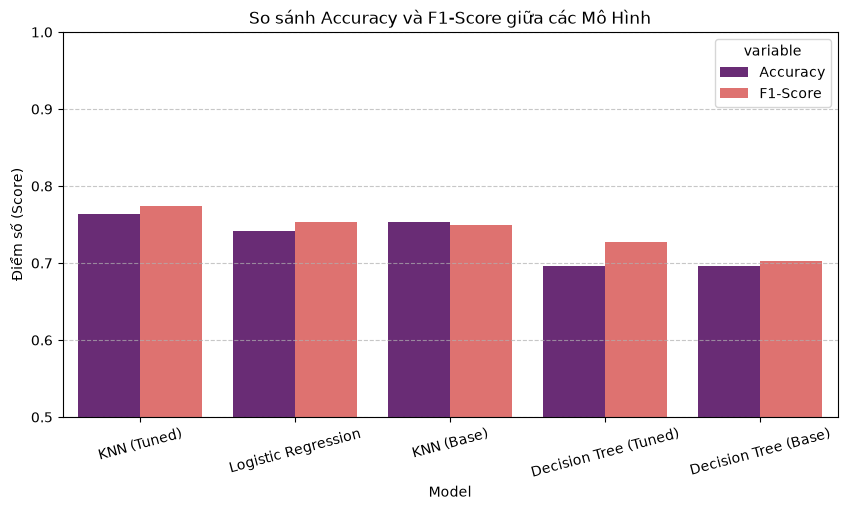

In [76]:
# Đánh giá mô hình ban đầu để so sánh
res_knn_base = evaluate_model('KNN (Base)', y_test, y_pred_knn)
res_dtree_base = evaluate_model('Decision Tree (Base)', y_test, y_pred_dtree)

# Tổng hợp kết quả thành DataFrame
df_results = pd.DataFrame([
    res_log_reg, 
    res_knn_base, 
    res_knn_tuned, 
    res_dtree_base, 
    res_dtree_tuned
])

df_results = df_results.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

print(' BẢNG SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH:')
print(df_results)

# Biểu đồ so sánh F1-Score và Accuracy
plt.figure(figsize=(10, 5))
df_melted = df_results.melt(id_vars='Model', value_vars=['Accuracy', 'F1-Score'])
sns.barplot(data=df_melted, x='Model', y='value', hue='variable', palette='magma')
plt.title('So sánh Accuracy và F1-Score giữa các Mô Hình')
plt.ylabel('Điểm số (Score)')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##  9. Bài Tập Thực Hành Tự Luyện (Hands-on Exercises)
1. **Thực hành Tinh chỉnh Logistic Regression**:
   Dùng `GridSearchCV` để tìm siêu tham số `C` trong khoảng `[0.01, 0.1, 1, 10, 100]` và `penalty` (`['l1', 'l2']` với solver `'liblinear'`).
2. **Thử nghiệm Bộ dữ liệu Breast Cancer**:
   Sử dụng dataset `load_breast_cancer()` từ `sklearn.datasets` và thực hiện lại 5 bước Machine Learning Workflow trên.

In [81]:
#Bài 1
param_grid_log_reg = {
    'C': [0.01, 0.1, 1, 10, 100],  # Mức độ phạt (C càng nhỏ phạt càng nặng)
    'penalty': ['l1', 'l2'],  # Chuẩn hóa L1 (Lasso) hoặc L2 (Ridge)
}
# 2. Khởi tạo GridSearchCV (sử dụng solver='liblinear' để hỗ trợ cả l1 và l2)
grid_log_reg = GridSearchCV(
    estimator=LogisticRegression(solver='liblinear', random_state=42),
    param_grid=param_grid_log_reg,
    cv=5,
    scoring='f1',
)
# 3. Huấn luyện (fit) tìm tham số tối ưu trên tập Train đã scale
grid_log_reg.fit(X_train_scaled, y_train)
# 4. In ra bộ siêu tham số tốt nhất tìm được
print(
    'Siêu tham số Logistic Regression tốt nhất:', grid_log_reg.best_params_
)
print(
    f'Best F1-Score trên tập Cross-Validation: {grid_log_reg.best_score_:.4f}'
)
# 5. Dự đoán bằng mô hình tối ưu trên tập Test và đánh giá
best_log_reg = grid_log_reg.best_estimator_
y_pred_best_log_reg = best_log_reg.predict(X_test_scaled)
res_log_reg_tuned = evaluate_model(
    'Logistic Regression (Tuned)', y_test, y_pred_best_log_reg
)

Siêu tham số Logistic Regression tốt nhất: {'C': 0.01, 'penalty': 'l2'}
Best F1-Score trên tập Cross-Validation: 0.7631
==================== Logistic Regression (Tuned) ====================
Accuracy : 0.7753
Precision: 0.7500
Recall   : 0.8182
F1-Score : 0.7826

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.73      0.77        45
           1       0.75      0.82      0.78        44

    accuracy                           0.78        89
   macro avg       0.78      0.78      0.78        89
weighted avg       0.78      0.78      0.77        89



c:\Users\d3s1g\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\d3s1g\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\d3s1g\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default va

In [ ]:
#Bài 2
cancer_data = load_breast_cancer(as_frame=True)
X_cancer = cancer_data.data  # 30 đặc trưng sinh học
y_cancer = cancer_data.target  # Nhãn: 0 (Ác tính - Malignant), 1 (Lành tính - Benign)
print(f'Kích thước dữ liệu Breast Cancer: {X_cancer.shape}')
print(f'Phân bố nhãn target:\n{y_cancer.value_counts()}')
# Chia 80% Train, 20% Test
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer
)
# Chuẩn hóa đặc trưng bằng StandardScaler
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)
print(
    f'Số mẫu Train: {X_train_c_scaled.shape[0]}, Số mẫu Test: {X_test_c_scaled.shape[0]}'
)
# 1. Logistic Regression
log_reg_c = LogisticRegression(random_state=42)
log_reg_c.fit(X_train_c_scaled, y_train_c)
y_pred_log_c = log_reg_c.predict(X_test_c_scaled)
res_log_c = evaluate_model(
    'Cancer - Logistic Regression', y_test_c, y_pred_log_c
)
# 2. KNN
knn_c = KNeighborsClassifier(n_neighbors=5)
knn_c.fit(X_train_c_scaled, y_train_c)
y_pred_knn_c = knn_c.predict(X_test_c_scaled)
res_knn_c = evaluate_model('Cancer - KNN', y_test_c, y_pred_knn_c)
# 3. Decision Tree
dtree_c = DecisionTreeClassifier(max_depth=3, random_state=42)
dtree_c.fit(X_train_c_scaled, y_train_c)
y_pred_dtree_c = dtree_c.predict(X_test_c_scaled)
res_dtree_c = evaluate_model('Cancer - Decision Tree', y_test_c, y_pred_dtree_c)

param_grid_cancer = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
}
grid_cancer = GridSearchCV(
    KNeighborsClassifier(), param_grid_cancer, cv=5, scoring='f1'
)
grid_cancer.fit(X_train_c_scaled, y_train_c)
print('Siêu tham số KNN tốt nhất:', grid_cancer.best_params_)
# Dự đoán với mô hình tối ưu nhất
best_knn_c = grid_cancer.best_estimator_
y_pred_best_knn_c = best_knn_c.predict(X_test_c_scaled)
res_knn_c_tuned = evaluate_model(
    'Cancer - KNN (Tuned)', y_test_c, y_pred_best_knn_c
)
# TỔNG HỢP VÀ SO SÁNH KẾT QUẢ

df_cancer_results = pd.DataFrame(
    [res_log_c, res_knn_c, res_dtree_c, res_knn_c_tuned]
)
df_cancer_results = df_cancer_results.sort_values(
    by='F1-Score', ascending=False
).reset_index(drop=True)
print('\n=== BẢNG SO SÁNH HIỆU NĂNG BỘ DỮ LIỆU BREAST CANCER ===')
print(df_cancer_results)

Kích thước dữ liệu Breast Cancer: (569, 30)
Phân bố nhãn target:
target
1    357
0    212
Name: count, dtype: int64
Số mẫu Train: 455, Số mẫu Test: 114
==================== Cancer - Logistic Regression ====================
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1-Score : 0.9861

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

==================== Cancer - KNN ====================
Accuracy : 0.9561
Precision: 0.9589
Recall   : 0.9722
F1-Score : 0.9655

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                         